# Striatum Separation between Dorsal and Ventral striatum

This notebook does **not** rerun Cellpose. It re-uses the per-object fiber table [striatum_fiber_objects.csv](../outputs/2_cellpose_striatum_counts/tables/striatum_fiber_objects.csv) produced by the previous script [2_striatum_cellpose_fiber_counting_pipeline.ipynb](../notebooks/2_striatum_cellpose_fiber_counting_pipeline.ipynb). 

It will separate the striatum between the more dorsal region (Caudate and Putamen) and the Ventral Region (Nucleus Accumbens). 

### Requirements
To run this script: 
- The following manual ROIs should have be defined as *.roi* files in FIJI: Striatum_R, Striatum_L
- Segment the line splitting the ROIs mentionned above based on atlas definition: sep_R, sep_L (to segment Striatum_R and Striatum_L respectively)
- If this notebook is run on your data, [2_striatum_cellpose_fiber_counting_pipeline.ipynb](../notebooks/2_striatum_cellpose_fiber_counting_pipeline.ipynb) must be run before to obtain the [striatum_fiber_objects.csv](../outputs/2_cellpose_striatum_counts/tables/striatum_fiber_objects.csv) table.

    ![Striatum ROIS](../images/representation_striatum_ROIs.png)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile
from roifile import ImagejRoi

from utils import *

## 1. Parameters


In [2]:
PROJECT_DIR = Path("../")

RAW_IMAGE_DIR = PROJECT_DIR / "data" / "tiff_files"
ROI_DIR = PROJECT_DIR / "data" / "roi_zip"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "3_ventral_dorsal_segmentation"
TABLE_DIR = PROJECT_DIR / "outputs" / "2_cellpose_striatum_counts" / "tables"

OBJECTS_CSV = TABLE_DIR / "striatum_fiber_objects.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not OBJECTS_CSV.exists():
    raise FileNotFoundError(
        f"{OBJECTS_CSV} not found. Run notebook 2_striatum_cellpose_fiber_counting_pipeline first "
        f"(this notebook only re-reads that table, it does not run Cellpose)."
    )

objects_df = pd.read_csv(OBJECTS_CSV)

In [3]:
samples = match_images_to_rois(RAW_IMAGE_DIR, ROI_DIR)
samples

,sample_id,image_path,roi_zip_path
0,demo_image,../data/tiff_files/demo_image.tif,../data/roi_zip/demo_image_RoiSet.zip


## 2. Per-image dorsal/ventral areas from `sep_R` / `sep_L`

For every image in `samples`, load its `RoiSet.zip`, find `Striatum_R`, `Striatum_L`, `sep_R`, `sep_L`, and compute the dorsal/ventral pixel area for each side. Images whose RoiSet doesn't have `sep_R`/`sep_L` yet (or can't be resolved) are skipped and reported below rather than failing the whole run.


In [4]:
area_records = []
line_records = []
skipped = []

for _, sample in samples.iterrows():

    sample_id = str(sample["sample_id"])

    try:
        image_path = sample["image_path"]
        image_file = image_path.name

        roi_path = sample["roi_zip_path"]
        rois = ImagejRoi.fromfile(roi_path)

        cpu_r = get_roi_by_name(rois, "Striatum_R")
        cpu_l = get_roi_by_name(rois, "Striatum_L")
        sep_r = get_roi_by_name(rois, "sep_R")
        sep_l = get_roi_by_name(rois, "sep_L")

        with tifffile.TiffFile(image_path) as tif:
            image_shape = tif.pages[0].shape[:2]

    except (FileNotFoundError, ValueError) as e:
        skipped.append((sample_id, str(sample.get("image_path", "?")), str(e)))
        continue

    r_dorsal_area, r_ventral_area, r_total_area = split_roi_area(cpu_r, sep_r, image_shape)
    l_dorsal_area, l_ventral_area, l_total_area = split_roi_area(cpu_l, sep_l, image_shape)

    for side, dorsal_area, ventral_area in [
        ("right", r_dorsal_area, r_ventral_area),
        ("left", l_dorsal_area, l_ventral_area),
    ]:
        for region, area_px in [("dorsal", dorsal_area), ("ventral", ventral_area)]:
            area_records.append({
                "sample_id": sample_id,
                "image_file": image_file,
                "side": side,
                "region": region,
                "area_px": area_px,
            })

    r_x1, r_y1, r_x2, r_y2 = get_line_endpoints(sep_r)
    l_x1, l_y1, l_x2, l_y2 = get_line_endpoints(sep_l)

    line_records.append({"sample_id": sample_id, "image_file": image_file, "side": "right",
                          "line_x1": r_x1, "line_y1": r_y1, "line_x2": r_x2, "line_y2": r_y2})
    line_records.append({"sample_id": sample_id, "image_file": image_file, "side": "left",
                          "line_x1": l_x1, "line_y1": l_y1, "line_x2": l_x2, "line_y2": l_y2})

area_df = pd.DataFrame(area_records)
line_df = pd.DataFrame(line_records)

print(f"Computed dorsal/ventral areas for {area_df['sample_id'].nunique()} images.")

if skipped:
    print(f"\nSkipped {len(skipped)} image(s) (missing file, or no sep_R/sep_L ROI):")
    for sample_id, image_path, reason in skipped:
        print(f"  {sample_id} | {image_path}: {reason}")

area_df.head()

Computed dorsal/ventral areas for 1 images.


,sample_id,image_file,side,region,area_px
0,demo_image,demo_image.tif,right,dorsal,2976878
1,demo_image,demo_image.tif,right,ventral,1029075
2,demo_image,demo_image.tif,left,dorsal,2923451
3,demo_image,demo_image.tif,left,ventral,1118694


## 3. Classify each fiber object as dorsal or ventral

Merge the `sep_R`/`sep_L` line parameters onto every fiber object (matched on
`sample_id` + `image_file` + `side`), then compare each object's `centroid_y` to
the line's `y` at that object's `centroid_x`.


In [5]:
objects_df = objects_df.merge(line_df, on=["sample_id", "image_file", "side"], how="left")

line_y_at_centroid = line_y_at_x(
    objects_df["centroid_x"],
    objects_df["line_x1"], objects_df["line_y1"],
    objects_df["line_x2"], objects_df["line_y2"],
)

has_line = objects_df["line_x1"].notna()
objects_df["region"] = np.select(
    [has_line & (objects_df["centroid_y"] < line_y_at_centroid), has_line],
    ["dorsal", "ventral"],
    default="unclassified",
)

objects_df = objects_df.drop(columns=["line_x1", "line_y1", "line_x2", "line_y2"])

n_unclassified = (objects_df["region"] == "unclassified").sum()
objects_df.loc[objects_df["region"] == "unclassified", "region"] = np.nan
if n_unclassified:
    print(f"Warning: {n_unclassified} fiber objects could not be classified (missing sep_R/sep_L for their image).")

objects_out = OUTPUT_DIR / "striatum_fiber_objects_with_region.csv"
objects_df.to_csv(objects_out, index=False)
print("Saved:", objects_out)

objects_df.head()

Saved: ../outputs/3_ventral_dorsal_segmentation/striatum_fiber_objects_with_region.csv


,sample_id,image_file,side,roi_name,object_id,centroid_x,centroid_y,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,region
0,demo_image,demo_image.tif,right,CPu_R,53,5436.935428,1893.648517,2865,1859,5403,1933,5471,dorsal
1,demo_image,demo_image.tif,right,CPu_R,54,5093.092147,1914.074695,2865,1869,5056,1964,5129,dorsal
2,demo_image,demo_image.tif,right,CPu_R,55,5388.585091,1897.261135,2133,1869,5361,1931,5419,dorsal
3,demo_image,demo_image.tif,right,CPu_R,56,5535.170948,1929.170481,2141,1888,5501,1973,5566,dorsal
4,demo_image,demo_image.tif,right,CPu_R,57,4867.535534,1994.353421,8330,1891,4837,2077,4904,dorsal


## 4. QC: visualize `Striatum_R`/`Striatum_L`, the `sep` line, and classified fibers

For any `sample_id`, this overlays the raw image with the `Striatum_R`/`Striatum_L` outline (yellow), the `sep_R`/`sep_L` line (white), and every fiber centroid colored **red = dorsal**, **blue = ventral** — a direct visual check that the line and the dorsal/ventral call make sense. Call `plot_dorsal_ventral_qc(sample_id)` with any id from `samples` to check further images.


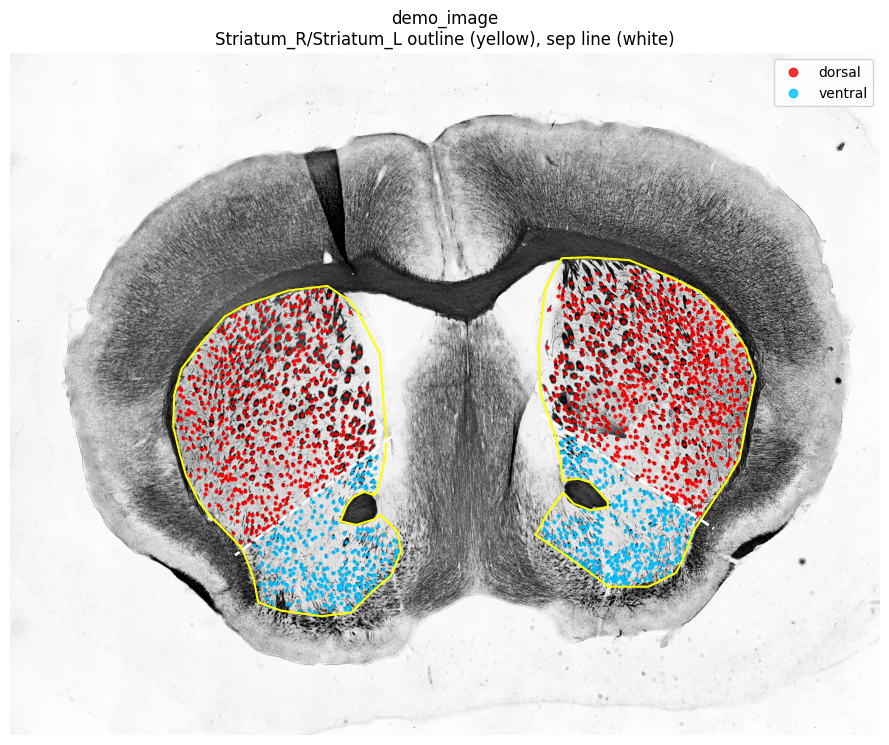

In [6]:
def plot_dorsal_ventral_qc(sample_id, downsample=4, figsize=(9, 8)):
    """QC overlay: raw image + Striatum_R/Striatum_L outline + sep_R/sep_L line + classified fiber centroids."""
    match = samples[samples["sample_id"].astype(str) == str(sample_id)]
    if match.empty:
        raise ValueError(f"No sample found for sample_id={sample_id!r}")
    sample = match.iloc[0]

    image_path = sample["image_path"]
    roi_path = sample["roi_zip_path"]
    image_file = image_path.name

    rois = ImagejRoi.fromfile(roi_path)
    cpu_r = get_roi_by_name(rois, "Striatum_R")
    cpu_l = get_roi_by_name(rois, "Striatum_L")
    sep_r = get_roi_by_name(rois, "sep_R")
    sep_l = get_roi_by_name(rois, "sep_L")

    img = tifffile.imread(image_path)
    if img.ndim == 3:
        img = img.mean(axis=2)
    height, width = img.shape
    display_img = normalize01(img[::downsample, ::downsample])

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(display_img, cmap="gray", extent=[0, width, height, 0])

    for roi in (cpu_r, cpu_l):
        coords = roi.coordinates()
        coords = np.vstack([coords, coords[:1]])  # close the polygon
        ax.plot(coords[:, 0], coords[:, 1], color="yellow", linewidth=1.5)

    for sep_roi in (sep_r, sep_l):
        x1, y1, x2, y2 = get_line_endpoints(sep_roi)
        ax.plot([x1, x2], [y1, y2], color="white", linewidth=2, linestyle="--")

    fibers = objects_df[
        (objects_df["sample_id"].astype(str) == str(sample_id))
        & (objects_df["image_file"] == image_file)
    ]
    region_colors = {"dorsal": "red", "ventral": "deepskyblue"}
    for region, color in region_colors.items():
        pts = fibers[fibers["region"] == region]
        ax.scatter(pts["centroid_x"], pts["centroid_y"], s=4, color=color, label=region, alpha=0.8)

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_title(f"{sample_id}\nStriatum_R/Striatum_L outline (yellow), sep line (white)")
    ax.legend(loc="upper right", markerscale=3)
    ax.axis("off")
    fig.tight_layout()
    return fig


for sample_id in area_df["sample_id"].unique():
    plot_dorsal_ventral_qc(sample_id)
    plt.show()

## 5. Total-striatum dorsal/ventral fiber counts, areas and densities

`Striatum_R` and `Striatum_L` are pooled into one "total striatum" per image (side isn't anatomically meaningful for these free-floating sections): fiber counts and pixel areas from both ROIs are summed per dorsal/ventral region, then `fiber_density = fiber_count / area_px`. Image/region combinations with zero fibers are kept (filled with 0) so areas are never silently dropped.


In [7]:
count_df = (
    objects_df.dropna(subset=["region"])
    .groupby(["sample_id", "image_file", "region"])
    .size()
    .reset_index(name="fiber_count")
)

area_total_df = (
    area_df
    .groupby(["sample_id", "image_file", "region"], as_index=False)["area_px"]
    .sum()
)

density_df = area_total_df.merge(
    count_df, on=["sample_id", "image_file", "region"], how="left"
)
density_df["fiber_count"] = density_df["fiber_count"].fillna(0).astype(int)
density_df["fiber_density"] = density_df["fiber_count"] / density_df["area_px"]

density_out = OUTPUT_DIR / "striatum_dorsal_ventral_density.csv"
density_df.to_csv(density_out, index=False)
print("Saved:", density_out)

density_df.sort_values(["sample_id", "region"])

Saved: ../outputs/3_ventral_dorsal_segmentation/striatum_dorsal_ventral_density.csv


,sample_id,image_file,region,area_px,fiber_count,fiber_density
0,demo_image,demo_image.tif,dorsal,5900329,1406,0.000238
1,demo_image,demo_image.tif,ventral,2147769,625,0.000291


## 6. Quick preview plot

Exploratory only -- for final statistics, use `striatum_dorsal_ventral_density.csv`.


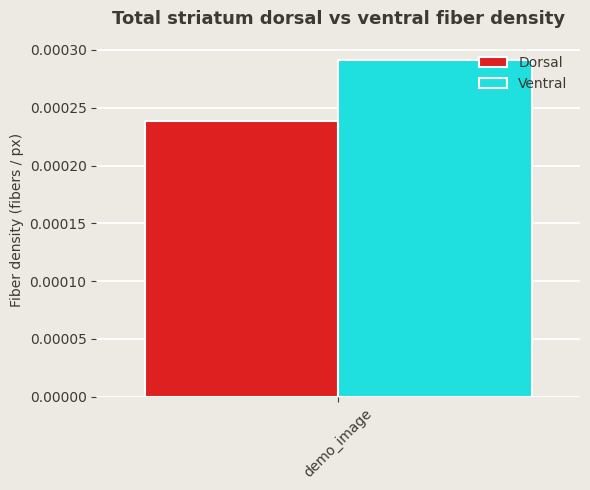

In [9]:
FIBER_COLORS = {
    "Dorsal": "red",
    "Ventral": "cyan"
}

BG_COLOR = "#EDEAE3"
TEXT_COLOR = "#3d3a34"

plot_df = density_df.copy()
plot_df["region"] = plot_df["region"].map({"dorsal": "Dorsal", "ventral": "Ventral"})

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.barplot(
    data=plot_df,
    x="sample_id",
    y="fiber_density",
    hue="region",
    hue_order=["Dorsal", "Ventral"],
    palette=FIBER_COLORS,
    edgecolor="white",
    linewidth=1.5,
    ax=ax,
)

ax.set_axisbelow(True)
ax.grid(axis="y", color="white", linewidth=1.3)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylabel("Fiber density (fibers / px)", color=TEXT_COLOR)
ax.set_xlabel("")
ax.set_title(
    "Total striatum dorsal vs ventral fiber density",
    color=TEXT_COLOR, fontsize=13, weight="bold", pad=14,
)
ax.tick_params(axis="x", colors=TEXT_COLOR, rotation=45)
ax.tick_params(axis="y", colors=TEXT_COLOR)

legend = ax.legend(frameon=False, title=None, loc="upper right")
for text in legend.get_texts():
    text.set_color(TEXT_COLOR)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "dorsal_ventral_density.png", dpi=300, facecolor=fig.get_facecolor())
plt.show()